In [5]:
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 2.3 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, Normalizer
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from My_Transformer import TransformerModel

In [7]:
df = pd.read_csv('KwhConsumptionBlower78_1.csv')
df = df[['TxnDate', 'TxnTime', 'Consumption']]
df.rename(columns={'TxnDate': 'date', 'TxnTime': 'time', 'Consumption': 'consumption'}, inplace=True)
df

,date,time,consumption
0,01 Jan 2022,16:55:52,1.010
1,01 Jan 2022,21:45:29,0.908
2,01 Jan 2022,12:24:52,0.926
3,01 Jan 2022,04:07:36,0.928
4,01 Jan 2022,06:52:25,0.916
...,...,...,...
1223,20 Jan 2022,21:43:55,5.128
1224,20 Jan 2022,09:43:03,5.924
1225,20 Jan 2022,03:06:05,4.664
1226,20 Jan 2022,06:16:38,3.474


In [8]:
df.reset_index(inplace=True)
df

,index,date,time,consumption
0,0,01 Jan 2022,16:55:52,1.010
1,1,01 Jan 2022,21:45:29,0.908
2,2,01 Jan 2022,12:24:52,0.926
3,3,01 Jan 2022,04:07:36,0.928
4,4,01 Jan 2022,06:52:25,0.916
...,...,...,...,...
1223,1223,20 Jan 2022,21:43:55,5.128
1224,1224,20 Jan 2022,09:43:03,5.924
1225,1225,20 Jan 2022,03:06:05,4.664
1226,1226,20 Jan 2022,06:16:38,3.474


In [9]:
df.isnull().sum()

index          0
date           0
time           0
consumption    0
dtype: int64

In [10]:
df['hour_start'] = df['time'].apply(lambda x: int(x[:2]))
df['hour_end'] = df['hour_start'].apply(lambda x: x + 1)
df['hour_range'] = df.apply(lambda row: f'{row["hour_start"]}-{row["hour_end"]}', axis=1)
df.drop(columns=['time', 'index'], inplace=True)

df

,date,consumption,hour_start,hour_end,hour_range
0,01 Jan 2022,1.010,16,17,16-17
1,01 Jan 2022,0.908,21,22,21-22
2,01 Jan 2022,0.926,12,13,12-13
3,01 Jan 2022,0.928,4,5,4-5
4,01 Jan 2022,0.916,6,7,6-7
...,...,...,...,...,...
1223,20 Jan 2022,5.128,21,22,21-22
1224,20 Jan 2022,5.924,9,10,9-10
1225,20 Jan 2022,4.664,3,4,3-4
1226,20 Jan 2022,3.474,6,7,6-7


In [11]:
# Grouping the data into time ranges, and get the mean if there are more data in that time range
df = df.groupby(by=['date', 'hour_range']).mean().sort_values(by=['date', 'hour_start', 'hour_end']).reset_index()
df['weekday'] = df['date'].apply(lambda x: pd.to_datetime(x).day_name())
df

,date,hour_range,consumption,hour_start,hour_end,weekday
0,01 Jan 2022,0-1,0.967000,0.0,1.0,Saturday
1,01 Jan 2022,1-2,1.377000,1.0,2.0,Saturday
2,01 Jan 2022,2-3,1.485000,2.0,3.0,Saturday
3,01 Jan 2022,3-4,0.929333,3.0,4.0,Saturday
4,01 Jan 2022,4-5,0.922667,4.0,5.0,Saturday
...,...,...,...,...,...,...
475,20 Jan 2022,19-20,6.758000,19.0,20.0,Thursday
476,20 Jan 2022,20-21,6.718000,20.0,21.0,Thursday
477,20 Jan 2022,21-22,5.202667,21.0,22.0,Thursday
478,20 Jan 2022,22-23,6.030667,22.0,23.0,Thursday


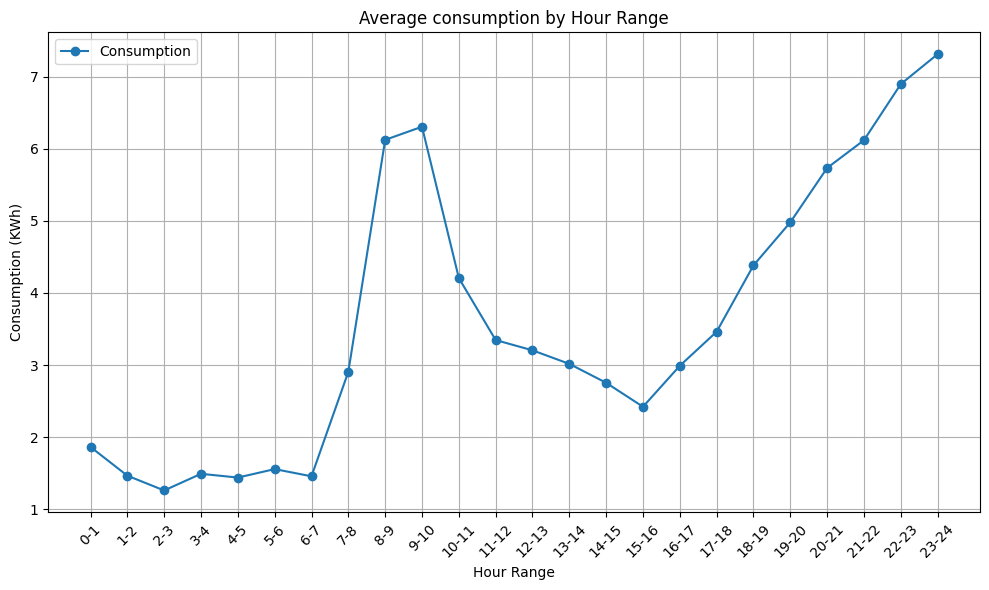

In [12]:
df_hourly_avg = df.groupby(by='hour_range')[['consumption', 'hour_start', 'hour_end']].mean().sort_values(by=['hour_start', 'hour_end'])['consumption']
plt.figure(figsize=(10, 6))
plt.plot(df_hourly_avg.index, df_hourly_avg, marker='o', linestyle='-', label='Consumption')
plt.xticks(rotation=45)
plt.xlabel('Hour Range')
plt.ylabel('Consumption (KWh)')
plt.title('Average consumption by Hour Range')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Check if all dates have all the hour ranges
ref_df = pd.DataFrame(df_hourly_avg).reset_index()
original_dates = df['date'].unique()
dates = pd.date_range(start=original_dates.min(), end=original_dates.max()).strftime('%d %b %Y')
hours = ref_df['hour_range']
full_grid = pd.MultiIndex.from_product([dates, hours], names=["date", "hour_range"]).to_frame(index=False)
merged = pd.merge(full_grid, df, on=["date", "hour_range"], how="left")
merged.isnull().sum() # No nulls

date           0
hour_range     0
consumption    0
hour_start     0
hour_end       0
weekday        0
dtype: int64

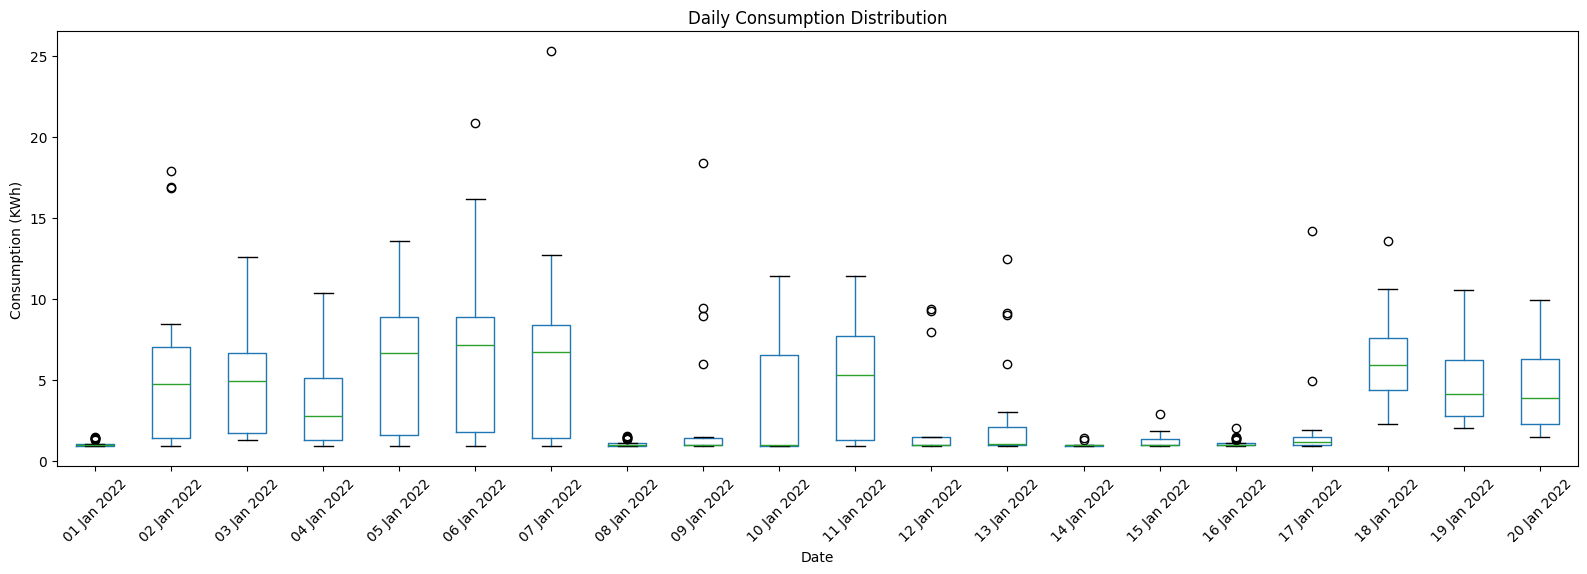

In [14]:
df.boxplot(column='consumption', by='date',grid=False, rot=45, figsize=(16, 6))
plt.title("Daily Consumption Distribution")
plt.suptitle("")
plt.xlabel("Date")
plt.ylabel("Consumption (KWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

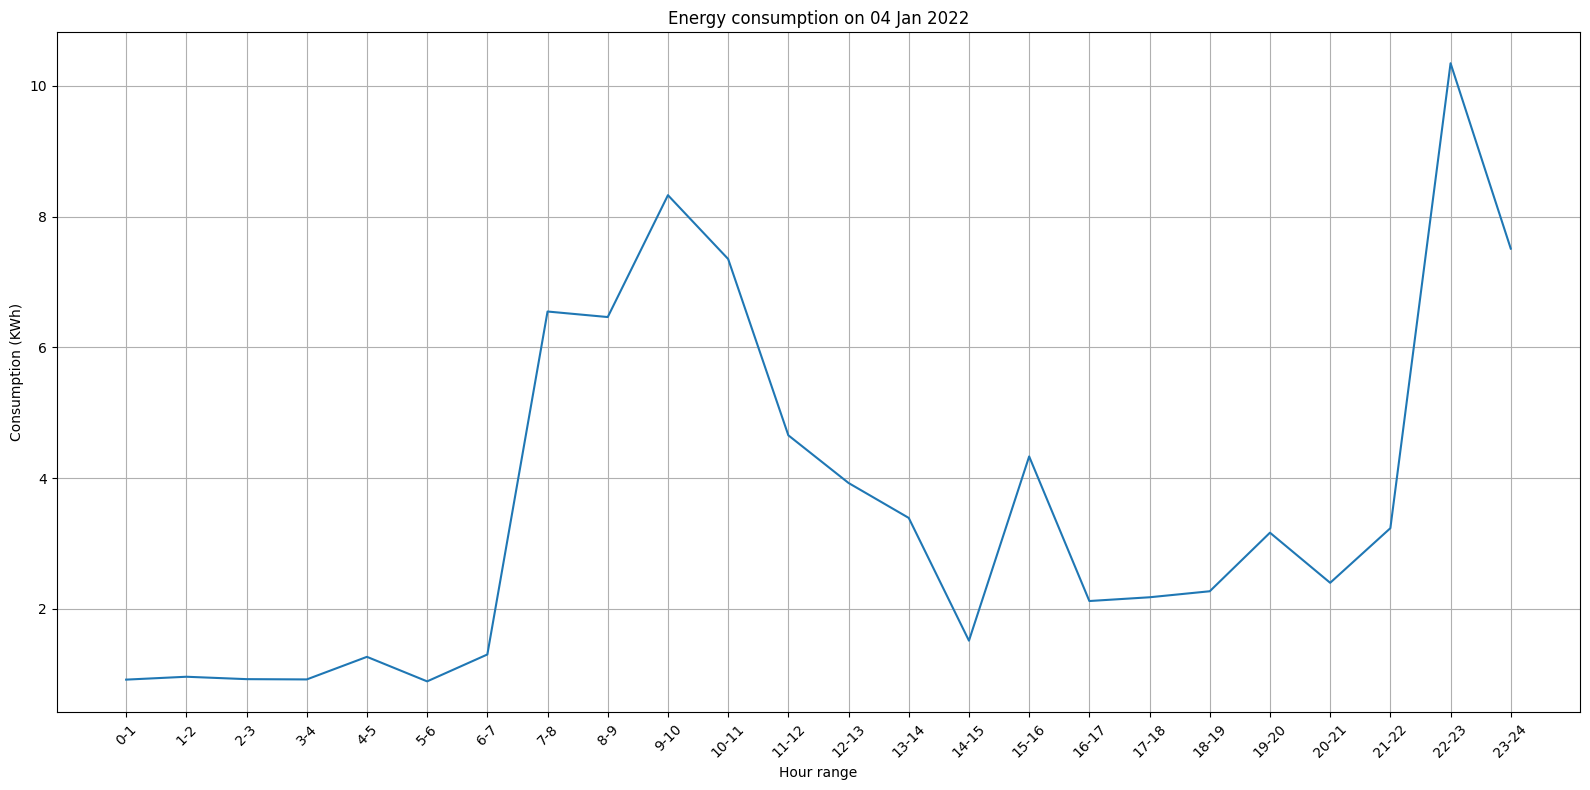

In [15]:
date = original_dates[3]
plt.figure(figsize=(16, 8))
temp_df = df.groupby('date').get_group(date).reset_index()[['hour_range', 'consumption']]
plt.plot(temp_df['hour_range'], temp_df['consumption'])
plt.title(f'Energy consumption on {date}')
plt.xlabel("Hour range")
plt.ylabel("Consumption (KWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [16]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_df = df.groupby('weekday')['consumption'].mean()
weekday_df.index = pd.CategoricalIndex(weekday_df.index, categories=weekday_order, ordered=True)
weekday_df.sort_index(inplace=True)
weekday_df

weekday
Monday       3.489042
Tuesday      4.901824
Wednesday    4.360352
Thursday     4.598081
Friday       3.704687
Saturday     1.114954
Sunday       3.146970
Name: consumption, dtype: float64

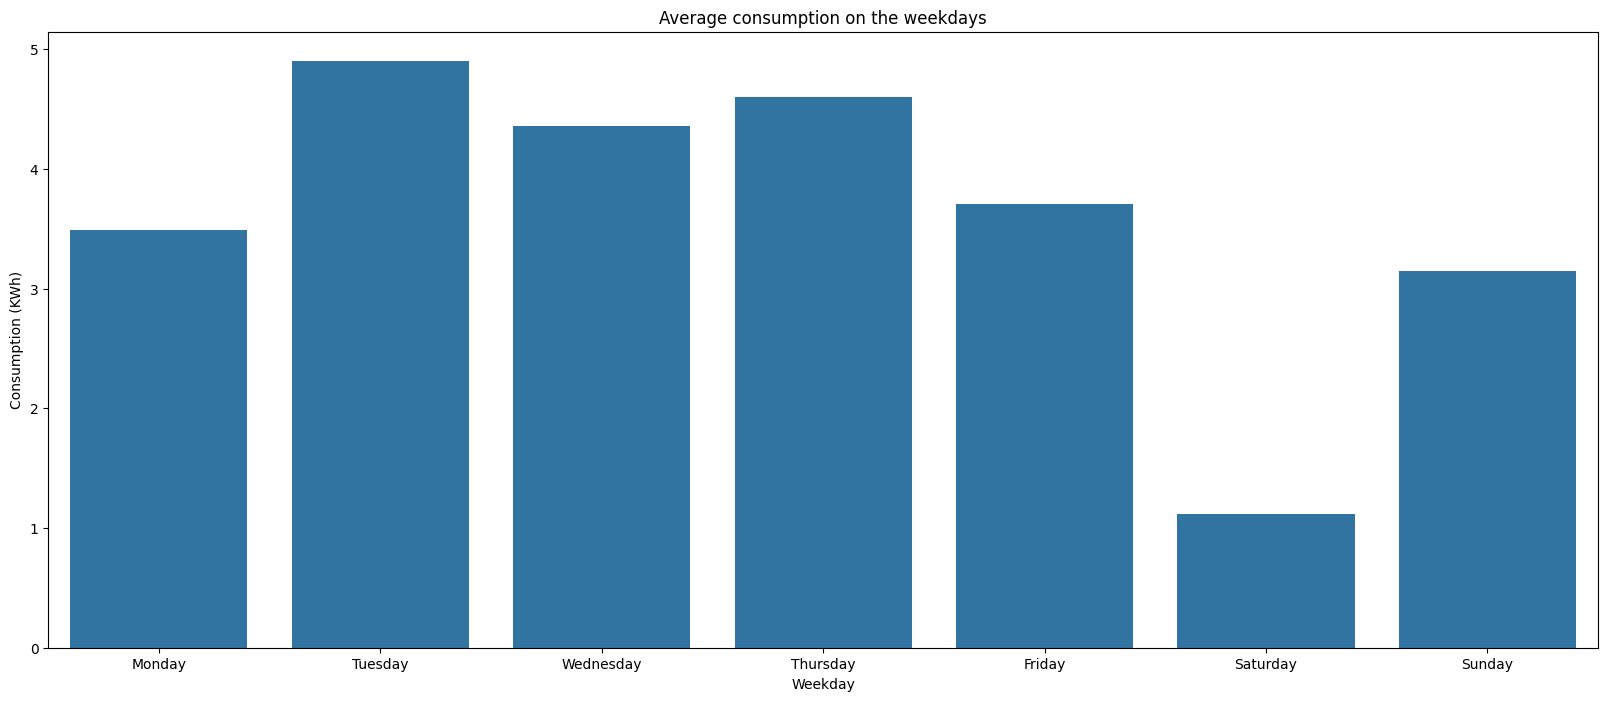

In [17]:
plt.figure(figsize=(20,8))
sns.barplot(weekday_df)
plt.xlabel('Weekday')
plt.ylabel('Consumption (KWh)')
plt.title('Average consumption on the weekdays')
plt.show()

In [18]:
timeseries = df['consumption'].to_numpy()
timeseries[:10]

array([0.967     , 1.377     , 1.485     , 0.92933333, 0.92266667,
       0.976     , 0.936     , 0.97      , 1.276     , 1.399     ])

In [19]:
train_size = int(len(timeseries) * 0.6)
valid_size = int(len(timeseries) * 0.2)
test_size = len(timeseries) - train_size - valid_size
train, valid, test = timeseries[:train_size], timeseries[train_size:train_size+valid_size],timeseries[train_size+valid_size:]

In [20]:
def create_dataset(dataset: np.ndarray, window: int):
    X = np.zeros(shape=(dataset.shape[0]-window, window, 1))
    y = np.zeros_like(X)
    for i in range(dataset.shape[0]-window):
        X[i, :, 0] =  dataset[i:i+window]
        y[i, :, 0] = dataset[i+1:i+1+window]
    return torch.tensor(X, dtype=torch.float), torch.tensor(y, dtype=torch.float)

In [21]:
window = 5
X_train, y_train = create_dataset(train, window)
X_val, y_val = create_dataset(valid, window)
X_test, y_test = create_dataset(test, window)
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

(torch.Size([283, 5, 1]),
 torch.Size([91, 5, 1]),
 torch.Size([91, 5, 1]),
 torch.Size([283, 5, 1]),
 torch.Size([91, 5, 1]),
 torch.Size([91, 5, 1]))

In [22]:
class LSTMModel(nn.Module):
    def __init__(self, in_features: int, hidden_features: int, out_features: int, num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(in_features, hidden_features, num_layers=num_layers, dropout=dropout, batch_first=True)
        self.linear = nn.Linear(hidden_features, out_features)

    def forward(self, x: torch.Tensor):
        out, _ = self.lstm(x) # (seq_length, hidden_features)
        out = self.linear(out) # (seq_length, out_features)
        return out

In [23]:
in_features = X_train.shape[-1]
hidden_features = 64
out_features = 1

model = LSTMModel(in_features, hidden_features, out_features, num_layers=2, dropout=0.2)
model(X_train).shape

torch.Size([283, 5, 1])

In [24]:
train_loader = DataLoader(TensorDataset(X_train, y_train), shuffle=True, batch_size=8)

In [25]:
loss_fn = nn.MSELoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 100
losses = []
val_losses = []
patience = 10
patience_counter = 0
best_loss = np.inf
best_state_dict = None
for epoch in range(num_epochs):
    epoch_loss = []
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    epoch_loss_mean = np.mean(epoch_loss)
    losses.append(epoch_loss_mean)
    model.eval()
    with torch.inference_mode():
        pred = model(X_val)
        loss = loss_fn(pred, y_val).item()
        val_losses.append(loss)
        if loss < best_loss:
            best_loss = loss
            patience_counter = 0
            best_state_dict = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stop')
                break        
    print(f'Epoch: {epoch + 1} | Loss: {epoch_loss_mean:.3f} | Val Loss: {loss:.3f}')
model.load_state_dict(best_state_dict)

Epoch: 1 | Loss: 26.264 | Val Loss: 4.944
Epoch: 2 | Loss: 15.927 | Val Loss: 4.075
Epoch: 3 | Loss: 11.863 | Val Loss: 2.100
Epoch: 4 | Loss: 8.380 | Val Loss: 1.385
Epoch: 5 | Loss: 7.666 | Val Loss: 1.572
Epoch: 6 | Loss: 7.372 | Val Loss: 1.206
Epoch: 7 | Loss: 7.206 | Val Loss: 1.221
Epoch: 8 | Loss: 6.922 | Val Loss: 1.384
Epoch: 9 | Loss: 7.110 | Val Loss: 1.185
Epoch: 10 | Loss: 6.749 | Val Loss: 1.454
Epoch: 11 | Loss: 6.754 | Val Loss: 1.396
Epoch: 12 | Loss: 6.648 | Val Loss: 1.324
Epoch: 13 | Loss: 6.526 | Val Loss: 1.452
Epoch: 14 | Loss: 6.448 | Val Loss: 1.304
Epoch: 15 | Loss: 6.626 | Val Loss: 1.483
Epoch: 16 | Loss: 6.408 | Val Loss: 1.369
Epoch: 17 | Loss: 6.584 | Val Loss: 1.322
Epoch: 18 | Loss: 6.314 | Val Loss: 1.409
Early stop


<All keys matched successfully>

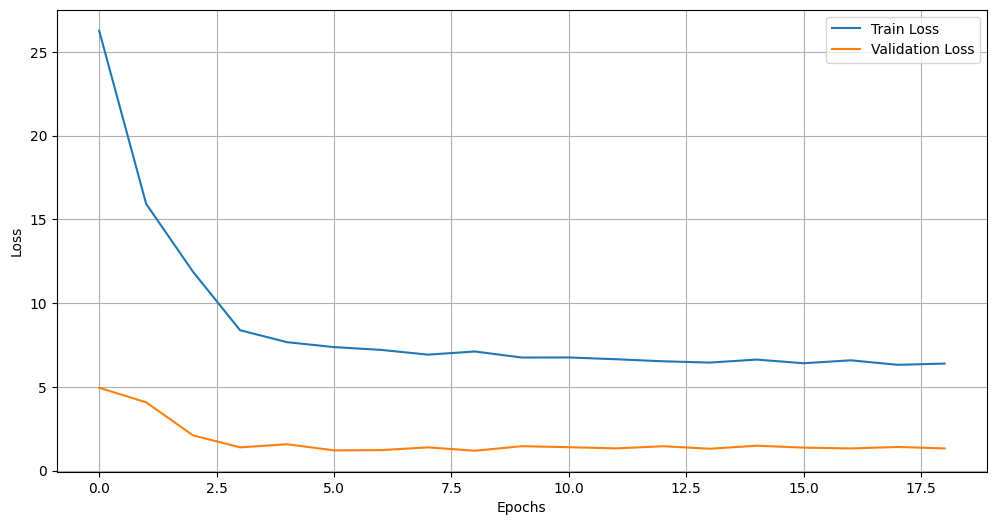

In [26]:
plt.figure(figsize=(12,6))
plt.plot(losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.grid()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

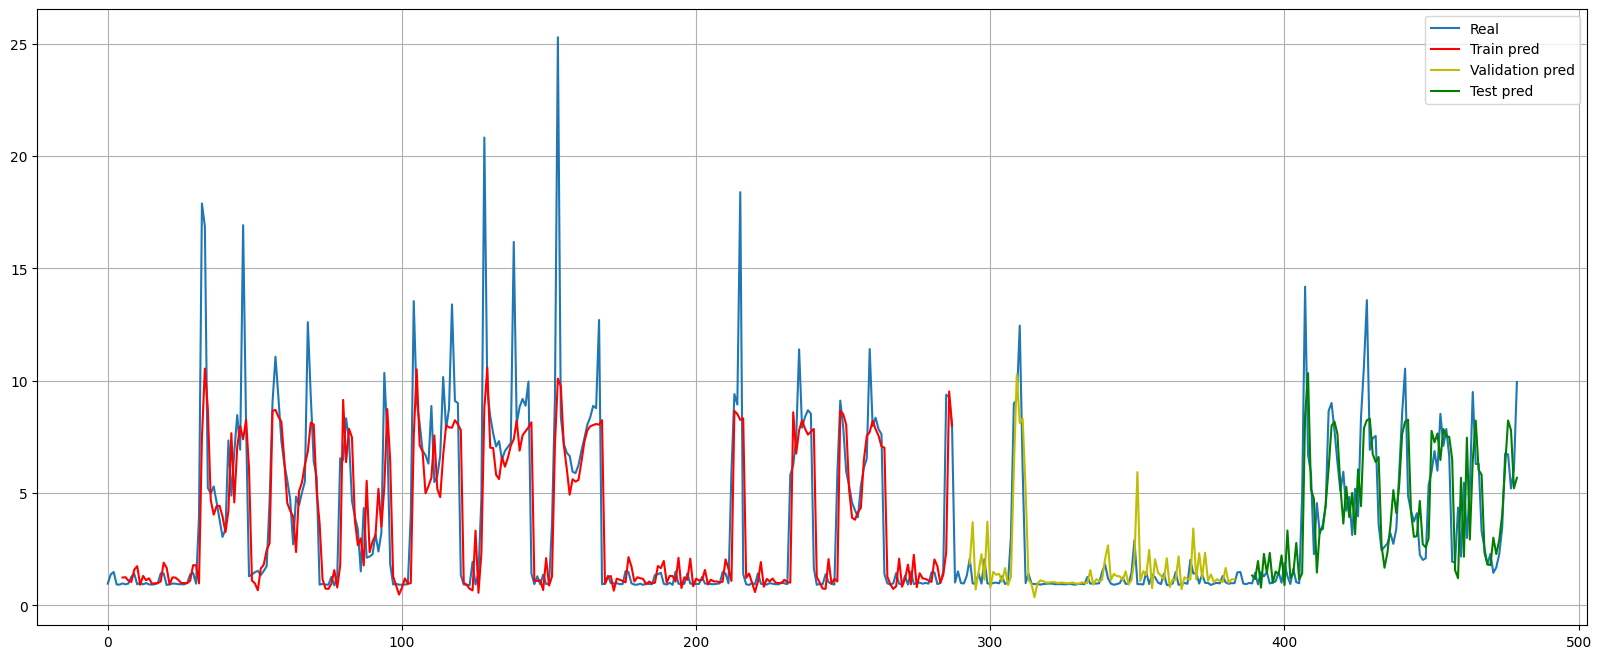

In [27]:
model.eval()
with torch.inference_mode():
    train_plot = (np.ones(shape=(timeseries.shape[0], 1)) * np.nan)[:,0]
    valid_plot = (np.ones_like(train_plot) * np.nan)
    test_plot = (np.ones_like(train_plot) * np.nan)
    train_plot[window:train_size] = model(X_train)[:, -1, -1]
    valid_plot[train_size+window:train_size+valid_size] = model(X_val)[:, -1, -1]
    test_plot[train_size+valid_size+window:len(timeseries)] = model(X_test)[:, -1, -1]
plt.figure(figsize=(20,8))
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(valid_plot, c='y')
plt.plot(test_plot, c='g')
plt.legend(['Real','Train pred', 'Validation pred', 'Test pred'])
plt.grid()
plt.show()

In [86]:
model = TransformerModel(num_layers=3,
                         input_dim=X_train.shape[-1],
                         seq_length=X_train.shape[1], 
                         embedding_dim=128,
                         hidden_dim=128,
                         num_heads=3,
                         out_dim=1
                         )

In [87]:
model(X_train, y_train).shape

torch.Size([283, 5, 1])

In [88]:
loss_fn = nn.MSELoss()
learning_rate = 0.0001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 100
losses = []
val_losses = []
patience = 10
patience_counter = 0
best_loss = np.inf
best_state_dict = None
for epoch in range(num_epochs):
    epoch_loss = []
    model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(x_batch, y_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    epoch_loss_mean = np.mean(epoch_loss)
    losses.append(epoch_loss_mean)
    model.eval()
    with torch.inference_mode():
        pred = model(X_val, y_val)
        loss = loss_fn(pred, y_val).item()
        val_losses.append(loss)
        if loss < best_loss:
            best_loss = loss
            patience_counter = 0
            best_state_dict = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stop')
                break        
    print(f'Epoch: {epoch + 1} | Loss: {epoch_loss_mean:.3f} | Val Loss: {loss:.3f}')
model.load_state_dict(best_state_dict)

Epoch: 1 | Loss: 19.671 | Val Loss: 2.140
Epoch: 2 | Loss: 15.478 | Val Loss: 1.965
Epoch: 3 | Loss: 14.323 | Val Loss: 1.853
Epoch: 4 | Loss: 13.658 | Val Loss: 1.849
Epoch: 5 | Loss: 13.111 | Val Loss: 1.725
Epoch: 6 | Loss: 12.243 | Val Loss: 1.431
Epoch: 7 | Loss: 10.731 | Val Loss: 1.217
Epoch: 8 | Loss: 10.109 | Val Loss: 1.134
Epoch: 9 | Loss: 9.465 | Val Loss: 1.062
Epoch: 10 | Loss: 8.807 | Val Loss: 0.980
Epoch: 11 | Loss: 8.302 | Val Loss: 0.925
Epoch: 12 | Loss: 7.937 | Val Loss: 0.895
Epoch: 13 | Loss: 7.505 | Val Loss: 0.810
Epoch: 14 | Loss: 7.351 | Val Loss: 0.737
Epoch: 15 | Loss: 6.652 | Val Loss: 0.673
Epoch: 16 | Loss: 6.362 | Val Loss: 0.622
Epoch: 17 | Loss: 6.015 | Val Loss: 0.591
Epoch: 18 | Loss: 6.034 | Val Loss: 0.554
Epoch: 19 | Loss: 5.833 | Val Loss: 0.518
Epoch: 20 | Loss: 5.255 | Val Loss: 0.499
Epoch: 21 | Loss: 5.094 | Val Loss: 0.443
Epoch: 22 | Loss: 4.935 | Val Loss: 0.417
Epoch: 23 | Loss: 4.666 | Val Loss: 0.399
Epoch: 24 | Loss: 4.469 | Val Loss:

<All keys matched successfully>

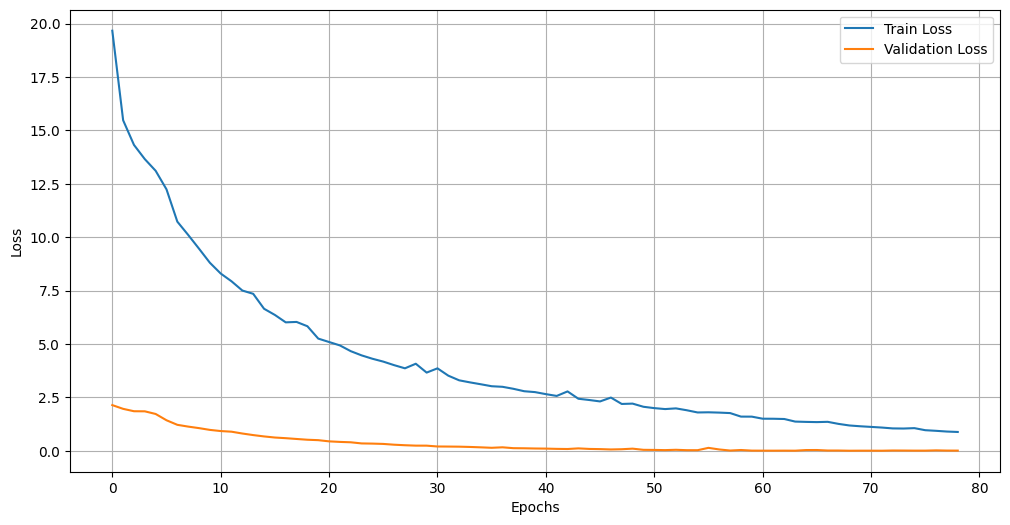

In [89]:
plt.figure(figsize=(12,6))
plt.plot(losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.grid()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

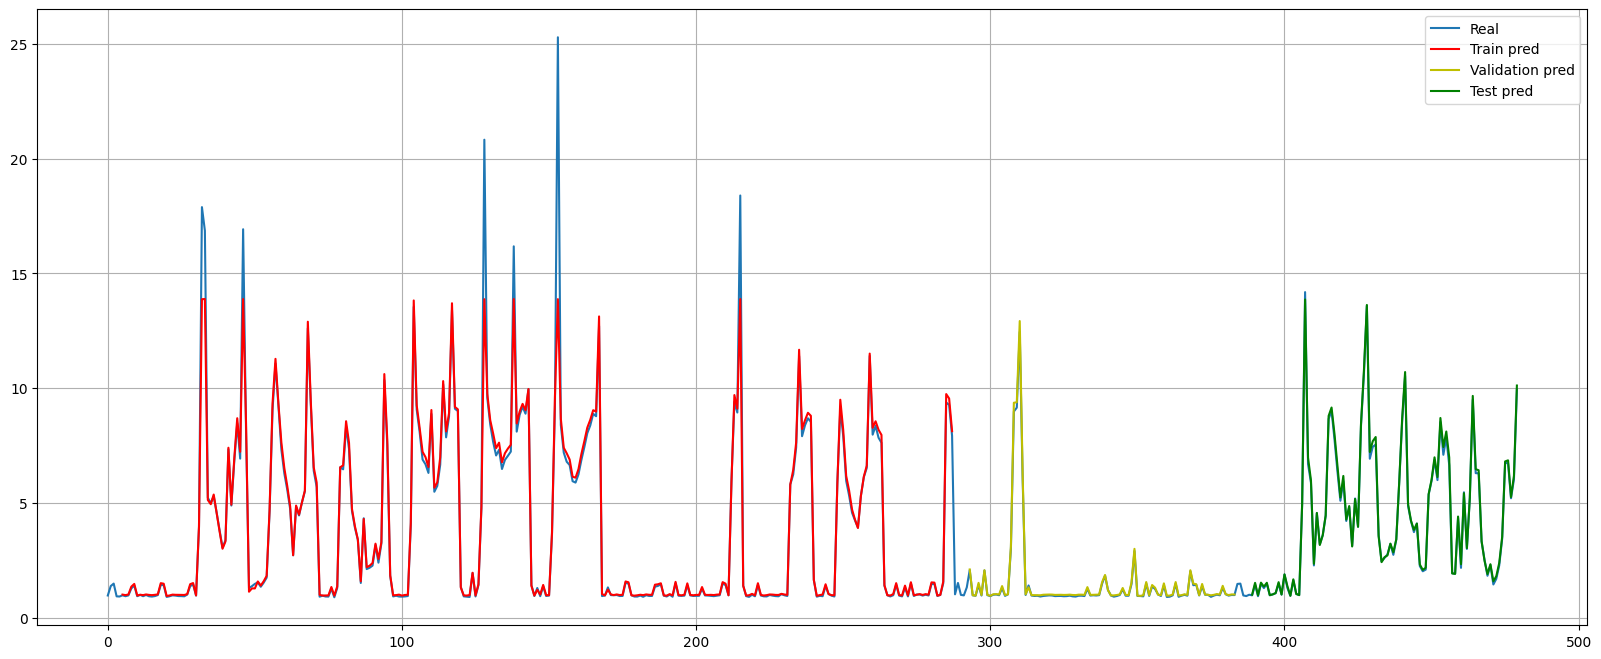

In [90]:
model.eval()
with torch.inference_mode():
    train_plot = (np.ones(shape=(timeseries.shape[0], 1)) * np.nan)[:,0]
    valid_plot = (np.ones_like(train_plot) * np.nan)
    test_plot = (np.ones_like(train_plot) * np.nan)
    train_plot[window:train_size] = model(X_train, y_train)[:, -1, -1]
    valid_plot[train_size+window:train_size+valid_size] = model(X_val, y_val)[:, -1, -1]
    test_plot[train_size+valid_size+window:len(timeseries)] = model(X_test, y_test)[:, -1, -1]
plt.figure(figsize=(20,8))
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(valid_plot, c='y')
plt.plot(test_plot, c='g')
plt.legend(['Real','Train pred', 'Validation pred', 'Test pred'])
plt.grid()
plt.show()